# 📊 3.1 — Escalamiento y Normalización de Variables
## 

**Objetivo:** Entender por qué y cómo escalar variables en un contexto de seguros.  


In [2]:
# Instalación e importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
print("✅ Librerías cargadas correctamente")


✅ Librerías cargadas correctamente


## 1. ¿Por qué necesitamos escalar? 🤔

Imagina que tienes dos variables en una póliza de seguro de auto:
- **Edad del conductor**: 18 a 80 años
- **Prima anual**: $5,000 a $150,000 pesos

Si un modelo compara estas variables directamente, la prima domina completamente por su magnitud. El escalamiento soluciona esto.


In [14]:
# Crear dataset actuarial de ejemplo
np.random.seed(42)
n = 500

df = pd.DataFrame({
    'edad_conductor': np.random.randint(18, 80, n),
    'antiguedad_licencia': np.random.randint(0, 45, n),
    'prima_anual': np.random.lognormal(mean=10, sigma=0.8, size=n).clip(5000, 150000),
    'suma_asegurada': np.random.lognormal(mean=13, sigma=0.5, size=n).clip(100000, 5000000),
    'num_siniestros_previos': np.random.poisson(lam=0.3, size=n),
})

print("📋 Primeras 5 filas del dataset:")
print(df.head())
print(f"\n📊 Estadísticas descriptivas:")
print(df.describe().round(2))


📋 Primeras 5 filas del dataset:
   edad_conductor  antiguedad_licencia   prima_anual  suma_asegurada  \
0              56                   21  44067.562681    6.068628e+05   
1              69                   22  32107.003572    2.712013e+05   
2              46                    1  16538.274489    5.275218e+05   
3              32                   26  45319.412406    4.727823e+05   
4              60                   41  10970.909910    1.035969e+06   

   num_siniestros_previos  
0                       1  
1                       0  
2                       1  
3                       0  
4                       1  

📊 Estadísticas descriptivas:
       edad_conductor  antiguedad_licencia  prima_anual  suma_asegurada  \
count          500.00               500.00       500.00          500.00   
mean            49.91                21.78     33707.36       522252.28   
std             18.22                12.69     30977.12       280798.88   
min             18.00                

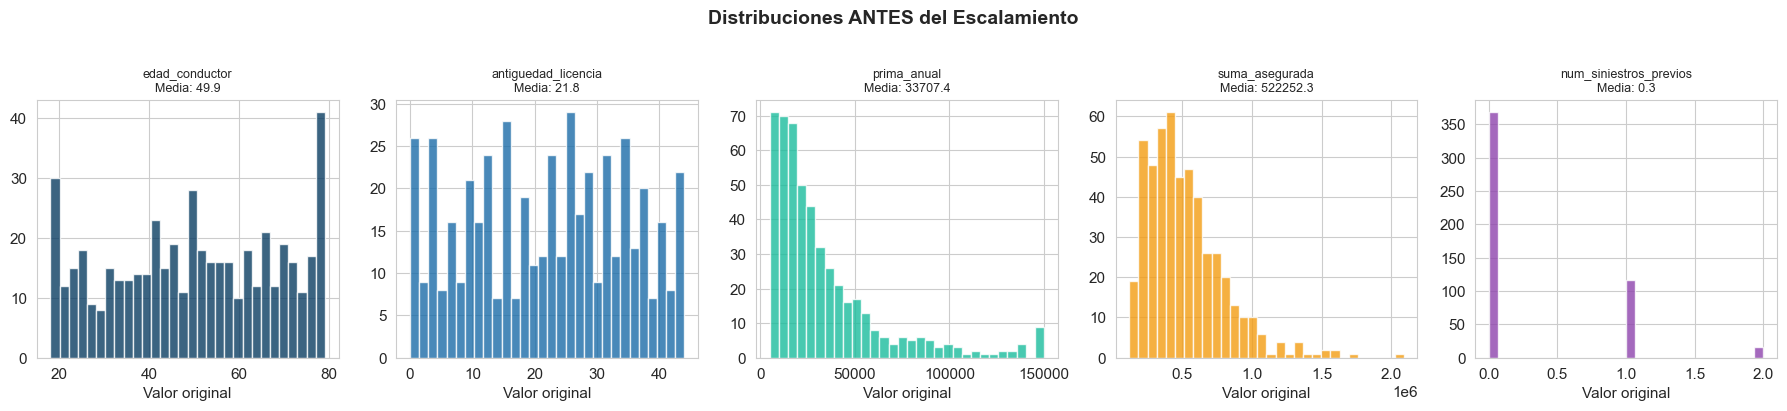

💡 Observa cómo prima_anual y suma_asegurada tienen rangos MUCHO mayores que edad


In [4]:
# Visualizar distribuciones ANTES del escalamiento
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
cols = df.columns.tolist()
colors = ['#0A3D62', '#1B6CA8', '#1ABC9C', '#F39C12', '#8E44AD']

for i, (col, ax, c) in enumerate(zip(cols, axes, colors)):
    ax.hist(df[col], bins=30, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(f'{col}\nMedia: {df[col].mean():.1f}', fontsize=9)
    ax.set_xlabel('Valor original')

plt.suptitle('Distribuciones ANTES del Escalamiento', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('escala_antes.png', dpi=120, bbox_inches='tight')
plt.show()
print("💡 Observa cómo prima_anual y suma_asegurada tienen rangos MUCHO mayores que edad")


## 2. Min-Max Scaling (Normalización)

**Fórmula:** `X' = (X - X_min) / (X_max - X_min)`

Transforma todas las variables al rango [0, 1].


In [11]:
# Aplicar Min-Max Scaling
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(df),
    columns=[f'{c}_mm' for c in df.columns]
)

print("📊 Estadísticas DESPUÉS de Min-Max:")
print(df_minmax.describe().round(4))
print("\n✅ Todos los valores están entre 0 y 1")

# Verificar con un ejemplo manual
prima_ejemplo = 75000
prima_norm = (prima_ejemplo - df['prima_anual'].min()) / (df['prima_anual'].max() - df['prima_anual'].min())
print(f"\n🔍 Ejemplo manual:")
print(f"   Prima = ${prima_ejemplo:,}")
print(f"   Prima normalizada = {prima_norm:.4f}")
print(f"   Verificación con sklearn: {scaler_minmax.transform([[df.loc[0,'edad_conductor'], df.loc[0,'antiguedad_licencia'], prima_ejemplo, df.loc[0,'suma_asegurada'], df.loc[0,'num_siniestros_previos']]])[0][2]:.4f}")


📊 Estadísticas DESPUÉS de Min-Max:
       edad_conductor_mm  antiguedad_licencia_mm  prima_anual_mm  \
count           500.0000                500.0000        500.0000   
mean              0.5231                  0.4949          0.1980   
std               0.2987                  0.2884          0.2136   
min               0.0000                  0.0000          0.0000   
25%               0.2787                  0.2500          0.0578   
50%               0.5246                  0.5000          0.1260   
75%               0.7869                  0.7273          0.2575   
max               1.0000                  1.0000          1.0000   

       suma_asegurada_mm  num_siniestros_previos_mm  
count           500.0000                   500.0000  
mean              0.2042                     0.1480  
std               0.1426                     0.2612  
min               0.0000                     0.0000  
25%               0.1051                     0.0000  
50%               0.1735    

## 3. Estandarización Z-Score

**Fórmula:** `Z = (X - μ) / σ`

Transforma las variables para que tengan **media = 0** y **desviación estándar = 1**.


In [6]:
# Aplicar Z-Score Standardization
scaler_zscore = StandardScaler()
df_zscore = pd.DataFrame(
    scaler_zscore.fit_transform(df),
    columns=[f'{c}_z' for c in df.columns]
)

print("📊 Estadísticas DESPUÉS de Z-Score:")
print(df_zscore.describe().round(4))
print("\n✅ Todas las variables tienen media ≈ 0 y desv. est. ≈ 1")

# Cálculo manual para verificar
col = 'prima_anual'
mu = df[col].mean()
sigma = df[col].std()
prima_z = (df[col] - mu) / sigma
print(f"\n🔍 Z-Score de prima_anual:")
print(f"   Media original: ${mu:,.0f}")
print(f"   Desv. Est.: ${sigma:,.0f}")
print(f"   Primer valor original: ${df[col].iloc[0]:,.0f}")
print(f"   Primer valor Z: {prima_z.iloc[0]:.4f}")
print(f"   Interpretación: está {prima_z.iloc[0]:.2f} desviaciones estándar de la media")


📊 Estadísticas DESPUÉS de Z-Score:
       edad_conductor_z  antiguedad_licencia_z  prima_anual_z  \
count          500.0000               500.0000       500.0000   
mean             0.0000                 0.0000         0.0000   
std              1.0010                 1.0010         1.0010   
min             -1.7529                -1.7179        -0.9277   
25%             -0.8191                -0.8501        -0.6567   
50%              0.0049                 0.0177        -0.3371   
75%              0.8839                 0.8066         0.2791   
max              1.5980                 1.7532         3.7579   

       suma_asegurada_z  num_siniestros_previos_z  
count          500.0000                  500.0000  
mean             0.0000                   -0.0000  
std              1.0010                    1.0010  
min             -1.4340                   -0.5672  
25%             -0.6959                   -0.5672  
50%             -0.2162                   -0.5672  
75%            

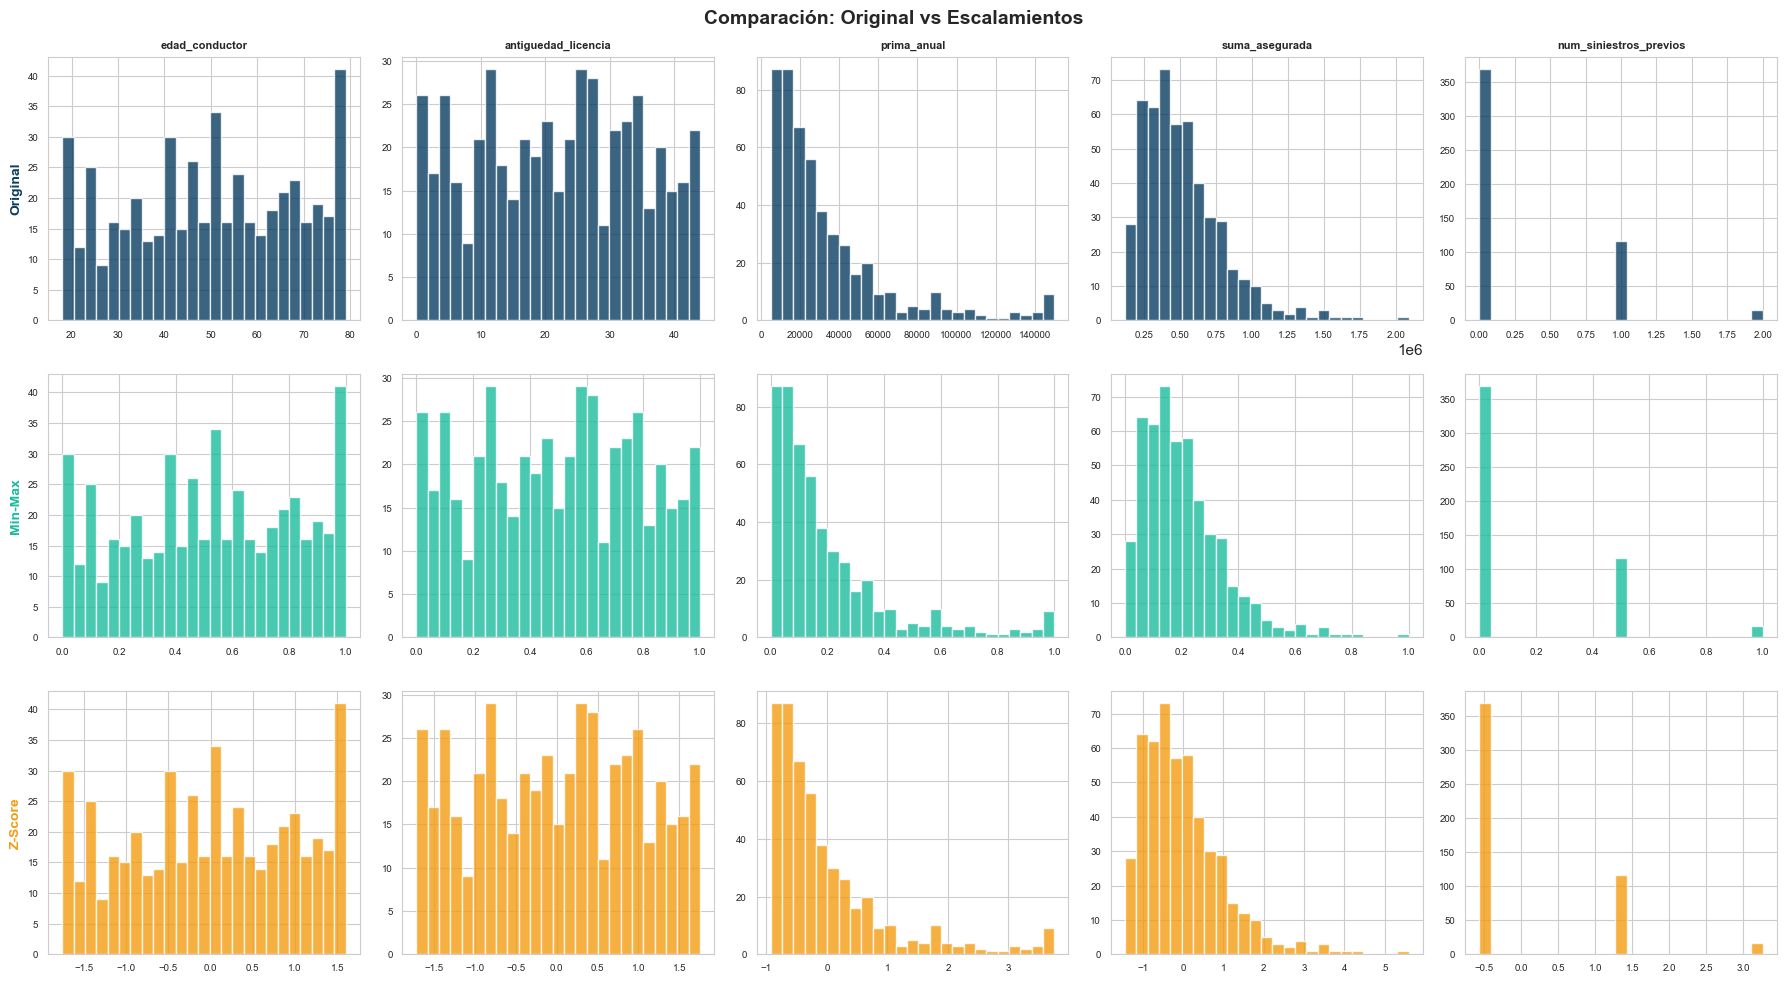

In [12]:
# Comparación visual: Original vs MinMax vs ZScore
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
col_names = df.columns.tolist()
titles = ['Original', 'Min-Max', 'Z-Score']
datasets = [df, df_minmax, df_zscore]
colors = ['#0A3D62', '#1ABC9C', '#F39C12']

for row, (data, title, c) in enumerate(zip(datasets, titles, colors)):
    for col_idx, col in enumerate(data.columns):
        ax = axes[row, col_idx]
        ax.hist(data[col], bins=25, color=c, alpha=0.8, edgecolor='white')
        if row == 0:
            ax.set_title(col_names[col_idx], fontsize=8, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(title, fontsize=10, fontweight='bold', color=c)
        ax.tick_params(labelsize=7)

plt.suptitle('Comparación: Original vs Escalamientos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparacion_escalamiento.png', dpi=120, bbox_inches='tight')
plt.show()


## 4. Robust Scaler — Para datos con outliers

Usa la **mediana** y el **rango intercuartil (IQR)** en lugar de media y desviación estándar.
Ideal cuando hay siniestros extremos o primas atípicas.


🚨 Estadísticas CON outliers en prima_anual:
  Media:  $      58,518
  Mediana: $     23,275
  Max:     $  3,646,669
  Min:     $      5,000


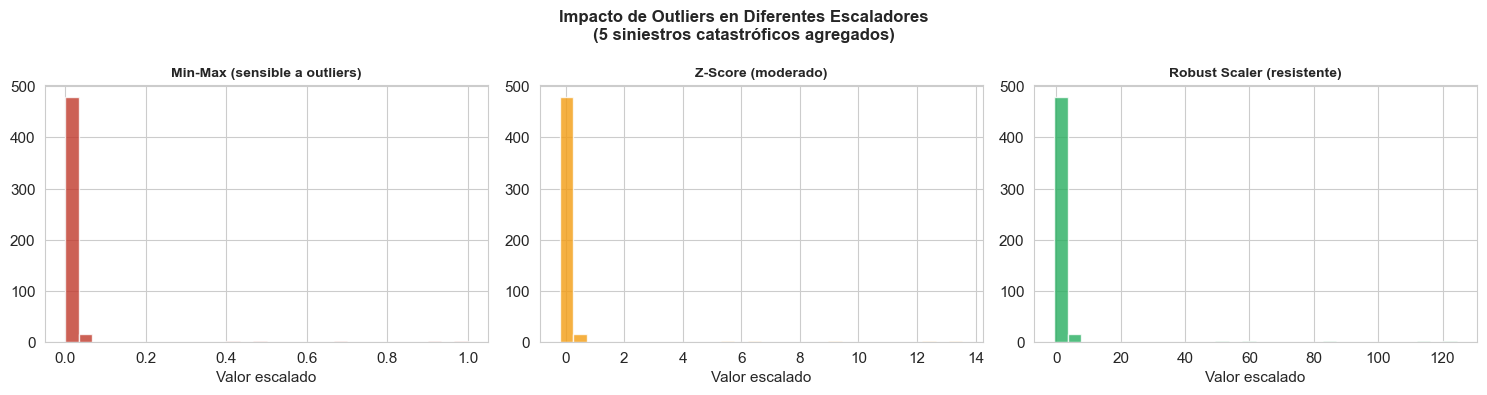


✅ Robust Scaler comprime los outliers sin distorsionar el resto


In [13]:
# Simular datos con outliers extremos (siniestros catastróficos)
df_con_outliers = df.copy()
# Agregar 5 siniestros con prima muy alta (catastróficos)
outlier_indices = np.random.choice(n, 5, replace=False)
df_con_outliers.loc[outlier_indices, 'prima_anual'] = np.random.uniform(1_000_000, 5_000_000, 5)

print("🚨 Estadísticas CON outliers en prima_anual:")
print(f"  Media:  ${df_con_outliers['prima_anual'].mean():>12,.0f}")
print(f"  Mediana: ${df_con_outliers['prima_anual'].median():>11,.0f}")
print(f"  Max:     ${df_con_outliers['prima_anual'].max():>11,.0f}")
print(f"  Min:     ${df_con_outliers['prima_anual'].min():>11,.0f}")

# Comparar escaladores
scaler_robust = RobustScaler()
scaler_standard = StandardScaler()
scaler_mm_out = MinMaxScaler()

prima_col = df_con_outliers[['prima_anual']]
prima_robust = scaler_robust.fit_transform(prima_col).flatten()
prima_standard = scaler_standard.fit_transform(prima_col).flatten()
prima_mm = scaler_mm_out.fit_transform(prima_col).flatten()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['Min-Max (sensible a outliers)', 'Z-Score (moderado)', 'Robust Scaler (resistente)']
datos = [prima_mm, prima_standard, prima_robust]
cols = ['#C0392B', '#F39C12', '#27AE60']

for ax, d, lab, c in zip(axes, datos, labels, cols):
    ax.hist(d, bins=30, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(lab, fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor escalado')

plt.suptitle('Impacto de Outliers en Diferentes Escaladores\n(5 siniestros catastróficos agregados)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('robust_scaler.png', dpi=120, bbox_inches='tight')
plt.show()
print("\n✅ Robust Scaler comprime los outliers sin distorsionar el resto")


# 📈 3.2 — Transformaciones Logarítmica, Box-Cox y Yeo-Johnson


**Objetivo:** Aprender a tratar distribuciones asimétricas típicas en seguros.  
**Contexto:** Los montos de siniestros en seguros de auto, vida y salud suelen ser muy asimétricos.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import boxcox, yeojohnson
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')
print("✅ Librerías cargadas")

In [ ]:
# Generar datos de siniestros (distribución muy asimétrica — log-normal)
np.random.seed(42)
n = 1000

montos_siniestros = np.random.lognormal(mean=9.5, sigma=1.2, size=n)  # Típico en seguros de auto
primas = np.random.lognormal(mean=9.8, sigma=0.6, size=n).clip(5000, 200000)
cambio_reservas = np.random.normal(0, 50000, n)  # Puede ser negativo

df = pd.DataFrame({
    'monto_siniestro': montos_siniestros,
    'prima_anual': primas,
    'cambio_reserva': cambio_reservas,
})

print("📊 Estadísticas de siniestros:")
print(f"  Media:    ${df['monto_siniestro'].mean():>12,.0f}")
print(f"  Mediana:  ${df['monto_siniestro'].median():>12,.0f}")
print(f"  Máximo:   ${df['monto_siniestro'].max():>12,.0f}")
print(f"  Asimetría: {df['monto_siniestro'].skew():.4f} (ideal: cercano a 0)")
print("\n💡 Asimetría > 1 indica distribución muy sesgada a la derecha")

## 1. Transformación Logarítmica

**Fórmula:** `Y' = log(Y + 1)`  
La más simple e intuitiva. Perfecta para montos de siniestros (siempre positivos).

In [ ]:
# Aplicar transformación logarítmica
df['log_siniestro'] = np.log1p(df['monto_siniestro'])  # log(Y + 1) — equivalente a log1p

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['monto_siniestro'], bins=50, color='#0A3D62', alpha=0.8, edgecolor='white')
axes[0].set_title(f'Monto Siniestros ORIGINAL\nAsimetría: {df["monto_siniestro"].skew():.2f}', fontweight='bold')
axes[0].set_xlabel('Monto ($)')

axes[1].hist(df['log_siniestro'], bins=50, color='#1ABC9C', alpha=0.8, edgecolor='white')
axes[1].set_title(f'Monto Siniestros LOG\nAsimetría: {df["log_siniestro"].skew():.2f}', fontweight='bold')
axes[1].set_xlabel('log(Monto + 1)')

plt.suptitle('Transformación Logarítmica en Siniestros de Auto', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('log_transform.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n✅ La asimetría bajó de {df['monto_siniestro'].skew():.2f} a {df['log_siniestro'].skew():.2f}")
print("\n🔄 Para recuperar el valor original: valor_original = exp(log_valor) - 1")
print(f"   Ejemplo: log_valor = {df['log_siniestro'].iloc[0]:.4f} → original = ${np.expm1(df['log_siniestro'].iloc[0]):,.0f}")

## 2. Transformación Box-Cox

**Fórmula:** `Y^(λ) = (Y^λ − 1)/λ` si λ≠0, `log(Y)` si λ=0  

El parámetro λ se **estima automáticamente** para maximizar la normalidad.  
⚠️ Solo funciona con valores **estrictamente positivos** (Y > 0).

In [ ]:
# Aplicar Box-Cox (requiere valores > 0)
y = df['monto_siniestro'].values
y_boxcox, lambda_optimo = boxcox(y)

print(f"🎯 Lambda óptimo encontrado: λ = {lambda_optimo:.4f}")
print(f"\n¿Qué significa?")
if abs(lambda_optimo) < 0.1:
    print("  → λ ≈ 0: equivale a transformación logarítmica")
elif abs(lambda_optimo - 0.5) < 0.1:
    print("  → λ ≈ 0.5: equivale a raíz cuadrada")
elif abs(lambda_optimo - 1) < 0.1:
    print("  → λ ≈ 1: sin transformación significativa")
else:
    print(f"  → Transformación potencial con exponente {lambda_optimo:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
datos = [y, np.log1p(y), y_boxcox]
labels = [f'Original\nAsim: {stats.skew(y):.2f}',
          f'Log(Y+1)\nAsim: {stats.skew(np.log1p(y)):.2f}',
          f'Box-Cox (λ={lambda_optimo:.2f})\nAsim: {stats.skew(y_boxcox):.2f}']
colors = ['#0A3D62', '#1B6CA8', '#F39C12']

for ax, d, lab, c in zip(axes, datos, labels, colors):
    ax.hist(d, bins=40, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(lab, fontweight='bold')
    # Agregar curva normal teórica
    xmin, xmax = ax.get_xlim()
    x_norm = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x_norm, d.mean(), d.std())
    ax_twin = ax.twinx()
    ax_twin.plot(x_norm, p, 'r-', linewidth=2, alpha=0.7, label='Normal')
    ax_twin.set_ylabel('')
    ax_twin.set_yticks([])

plt.suptitle('Comparación: Logarítmica vs Box-Cox', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxcox_transform.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Transformación Yeo-Johnson

La más versátil: acepta valores **negativos, cero y positivos**.  
Ideal para variables como:
- Cambio en reservas (puede ser positivo o negativo)
- Retorno de inversión
- Diferencia entre prima cobrada y siniestro pagado

In [ ]:
# Aplicar Yeo-Johnson (funciona con valores negativos)
y_negativo = df['cambio_reserva'].values  # Puede ser negativo

# Yeo-Johnson
y_yj, lambda_yj = yeojohnson(y_negativo)
y_log_abs = np.sign(y_negativo) * np.log1p(np.abs(y_negativo))  # Alternativa manual

print(f"📊 Datos de cambio en reservas:")
print(f"  Rango: ${y_negativo.min():,.0f} a ${y_negativo.max():,.0f}")
print(f"  Incluye negativos: {(y_negativo < 0).sum()} registros ({(y_negativo < 0).mean()*100:.1f}%)")
print(f"\n🎯 Lambda Yeo-Johnson óptimo: λ = {lambda_yj:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
datos_plot = [
    (y_negativo, 'Original', '#0A3D62'),
    (y_log_abs, 'Log con signo\n(alternativa simple)', '#1B6CA8'),
    (y_yj, f'Yeo-Johnson (λ={lambda_yj:.2f})', '#8E44AD'),
]

for ax, (d, lab, c) in zip(axes, datos_plot):
    ax.hist(d, bins=40, color=c, alpha=0.8, edgecolor='white')
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    ax.set_title(f'{lab}\nAsim: {stats.skew(d):.2f}', fontweight='bold')

plt.suptitle('Yeo-Johnson: Transformación para Cambio en Reservas\n(datos con valores negativos)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('yeojohnson_transform.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# Test de normalidad: ¿Cuánto mejoramos?
from scipy.stats import shapiro

variables_test = {
    'Original': df['monto_siniestro'].sample(500),
    'Log(Y+1)': df['log_siniestro'].sample(500),
    'Box-Cox': pd.Series(y_boxcox).sample(500),
}

print("=" * 55)
print("TEST DE NORMALIDAD (Shapiro-Wilk)")
print("H0: Los datos siguen distribución normal")
print("Si p-valor > 0.05 → No rechazamos normalidad")
print("=" * 55)

for nombre, data in variables_test.items():
    stat, p_valor = shapiro(data)
    decision = "✅ Normal" if p_valor > 0.05 else "❌ No normal"
    print(f"{nombre:15s} | Estadístico: {stat:.4f} | p-valor: {p_valor:.6f} | {decision}")

print("\n💡 Tip actuarial: Una distribución más simétrica mejora la")
print("   estimación de parámetros en GLMs y modelos de frecuencia/severidad")

In [ ]:
# Test de normalidad: ¿Cuánto mejoramos?
from scipy.stats import shapiro

variables_test = {
    'Original': df['cambio_reserva'].sample(1000),
    'Log': pd.Series(y_log_abs).sample(1000),
    'Yeo-Johnson': pd.Series(y_yj).sample(1000),
}

print("=" * 55)
print("TEST DE NORMALIDAD (Shapiro-Wilk)")
print("H0: Los datos siguen distribución normal")
print("Si p-valor > 0.05 → No rechazamos normalidad")
print("=" * 55)

for nombre, data in variables_test.items():
    stat, p_valor = shapiro(data)
    decision = "✅ Normal" if p_valor > 0.05 else "❌ No normal"
    print(f"{nombre:15s} | Estadístico: {stat:.4f} | p-valor: {p_valor:.6f} | {decision}")

print("\n💡 Tip actuarial: Una distribución más simétrica mejora la")
print("   estimación de parámetros en GLMs y modelos de frecuencia/severidad")

In [ ]:
# Aplicar transformación logarítmica
df['log_prima_anual'] = np.log1p(df['prima_anual'])  # log(Y + 1) — equivalente a log1p

# Aplicar Box-Cox (requiere valores > 0)
y = df['prima_anual'].values
y_boxcox, lambda_optimo = boxcox(y)


# Test de normalidad: ¿Cuánto mejoramos?
from scipy.stats import shapiro

variables_test = {
    'Original': df['prima_anual'].sample(500),
    'Log(Y+1)': df['log_prima_anual'].sample(500),
    'Box-Cox': pd.Series(y_boxcox).sample(500),
}

print("=" * 55)
print("TEST DE NORMALIDAD (Shapiro-Wilk)")
print("H0: Los datos siguen distribución normal")
print("Si p-valor > 0.05 → No rechazamos normalidad")
print("=" * 55)

for nombre, data in variables_test.items():
    stat, p_valor = shapiro(data)
    decision = "✅ Normal" if p_valor > 0.05 else "❌ No normal"
    print(f"{nombre:15s} | Estadístico: {stat:.4f} | p-valor: {p_valor:.6f} | {decision}")

print("\n💡 Tip actuarial: Una distribución más simétrica mejora la")
print("   estimación de parámetros en GLMs y modelos de frecuencia/severidad")